In [1]:
!pip install -U imbalanced-learn
!pip install --upgrade numexpr
!pip install --upgrade bottleneck


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


In [3]:
# Load dataset
df = pd.read_csv('creditcard.csv')
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# checking for null values
df.isnull().sum().max()

0

In [7]:
# Check for missing values
missing_values = df.isnull().sum().max()
display(missing_values)

0

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [9]:
# Analyze the class distribution
# This proves the data is HEAVILY imbalanced(skewed)

print("No frauds", round(df['Class'].value_counts()[0]/len(df)*100,2) , "% of the dataset")
print("Frauds", round(
    df['Class'].value_counts()[1]/len(df)*100,2) ,"% of the dataset")

No frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


Our original dataset is imbalanced right now, most of the transactions are not fraud if we train on this dataset as the base of our predictive models and analysis the model may get a lot of errors and our algorithms will probably be overfit since it will assume most of the transactions are not frauds. But we dont want our models to assume that we want our models to check for patterns and signs of fraud.

Text(0.5, 1.0, 'Class Distribution')

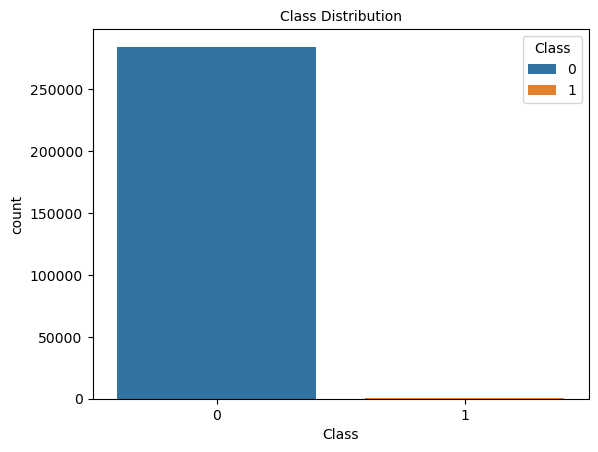

In [10]:
# Bar chart showing the count of Class 0 (non-fraud) vs Class 1 (fraud)
# You can clearly see the huge difference — the fraud bar is barely visible
# This visual confirms we need undersampling or oversampling to balance the classes

sns.countplot(x='Class', data=df, hue='Class')
plt.title("Class Distribution", fontsize=10)

As we can see on the above Countplot that how skewed are the features, we can also see the distributions of the other features. There are techniques that can help the distributions be less skewed, lets us see


Text(0.5, 1.0, 'Transaction Amount Distribution')

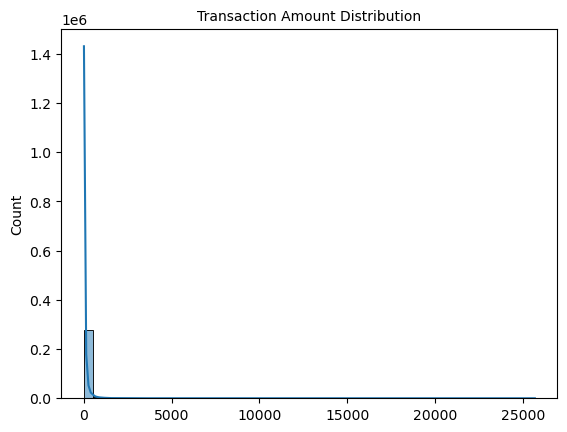

In [11]:
# Most transactions are small (under $200), with a long tail of large amounts
# This tells us Amount needs to be scaled — outliers will affect the model
sns.histplot(df['Amount'].values, bins=50, kde=True)
plt.title("Transaction Amount Distribution", fontsize=10)

Text(0.5, 1.0, 'Transaction Time Distribution')

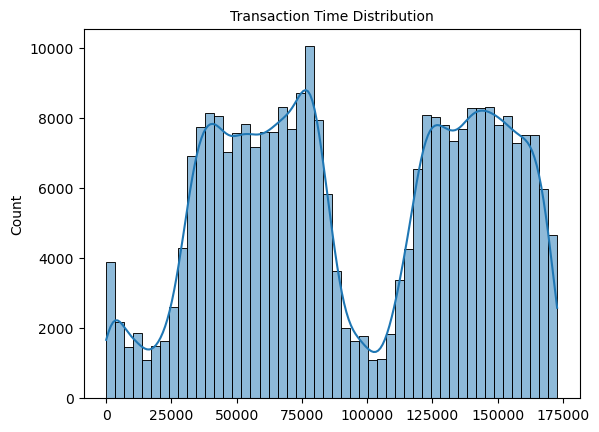

In [12]:
# The dips likely represent nighttime when fewer transactions occur
# Time also needs to be scaled so it does not dominate the model
sns.histplot(df['Time'].values, bins=50, kde=True)
plt.title("Transaction Time Distribution", fontsize=10)

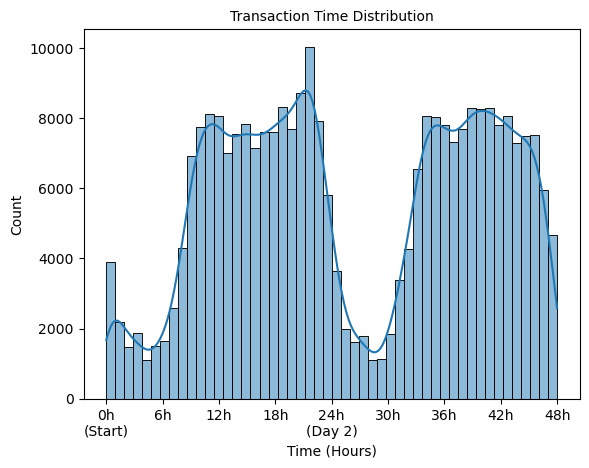

In [13]:
# The dips likely represent nighttime when fewer transactions occur
# Time also needs to be scaled so it does not dominate the model
# Converting seconds to hours for a clearer x-axis

time_in_hours = df['Time'].values / 3600  # convert seconds to hours

sns.histplot(time_in_hours, bins=50, kde=True)
plt.title("Transaction Time Distribution", fontsize=10)
plt.xlabel("Time (Hours)")

# Add custom x-axis labels showing actual time of day
# The data starts at some point, so we label in 6-hour blocks
tick_positions = [0, 6, 12, 18, 24, 30, 36, 42, 48]
tick_labels = ['0h\n(Start)', '6h', '12h', '18h', '24h\n(Day 2)', '30h', '36h', '42h', '48h']
plt.xticks(tick_positions, tick_labels)

plt.show()


In [14]:
standrad_sca = StandardScaler()
robust_sclr = RobustScaler()

df['scled_amt'] = robust_sclr.fit_transform(df['Amount'].values.reshape(-1,1))

In [15]:
# RobustScaler uses the median and IQR (interquartile range) instead of mean and std
# This makes it much better than StandardScaler when there are outliers (common in fraud)
# We create new scaled columns for Amount and Time, then drop the originals
standard_sca = StandardScaler()
robust_scaler = RobustScaler()

# RobustScaler is better for data with outliers (common in fraud)

df['scaled_amount'] = robust_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
# (.value) = gives 1D array (.reshape(-1,1)) functions converts it to give 2D array(rows and columns) which the scikit learn can accepts in robust scaler
df['scaled_time'] = robust_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)
df.head()
# amount and time has been scaled and dropped

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,scled_amt,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,0.670579,-0.994960


In [16]:
# we are going to move the scaled columns at the front
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)

# maving the desired columns to the front 
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,scled_amt
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579


In [17]:
# splitting the data before proceeding with random undersampling
# we are seperating the original dataframe for testing purpose 
# although we are splitting the data when implementing Random undersampling technique
# or Oversampling technique - we want to test our model on the original dataset 
# not on the splitted datset created by the techniques. The main goal is to fit the model 


X = df.drop(['Class'], axis=1)
y = df['Class']

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train", train_index, "Test", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]


# check the distribution of the labels 

print("Values")
original_Xtrain = original_Xtrain.values # converting to np arrays (scikit learn processes fast)
original_ytrain = original_ytrain.values
original_Xtest = original_Xtest.values
original_ytest = original_ytest.values


train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_count_label = np.unique(original_ytest, return_counts=True)
# train_unique_labels = unique values in original_ytrain, train_counts_label = nunber of unique values in orginal_ytrain

print('Label Distribution: \n' )
print(train_counts_label / len(original_ytrain))
print(test_count_label / len(original_ytest))

Train [ 30473  30496  31002 ... 284804 284805 284806] Test [    0     1     2 ... 57017 57018 57019]
Train [     0      1      2 ... 284804 284805 284806] Test [ 30473  30496  31002 ... 113964 113965 113966]
Train [     0      1      2 ... 284804 284805 284806] Test [ 81609  82400  83053 ... 170946 170947 170948]
Train [     0      1      2 ... 284804 284805 284806] Test [150654 150660 150661 ... 227866 227867 227868]
Train [     0      1      2 ... 227866 227867 227868] Test [212516 212644 213092 ... 284804 284805 284806]
Values
Label Distribution: 

[0.99827076 0.00172924]
[0.99827952 0.00172048]


## Random Undersampling 
Making the data more balanced dataset

Step 1 -  As we have already know how imbalanced our class column to determine the amount for each label
Step 2 - Once we get the number of frauds in the dataset, 
we should bring the same amount of no frauds from the datset to make a 50/50 ratio. 
Step 3 - After performing the 2nd step we have sub sample, the next step will be to shuffle the data
to check our model can maintain the accuracy everytime we run the script

In [18]:
print("No frauds", round(df['Class'].value_counts()[0]) , "of the dataset")
print("Frauds", round(df['Class'].value_counts()[1]) ,"of the dataset")

No frauds 284315 of the dataset
Frauds 492 of the dataset


In [19]:
# Since our model is highly skewed we should make them equivalent
# Lets shuffle the data before creating a subsampl

df = df.sample(frac=1)

# number of fraud cases in the dataset = 492
# we are taking 492 Non-frauds data which matches the frauds to make them equivalent 
fraud_df = df.loc[df['Class']==1]
non_fraud_df = df.loc[df['Class']==0][:492]

normal_distri_df = pd.concat([fraud_df, non_fraud_df])

new_df = normal_distri_df.sample(frac=1, random_state=42)

new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,scled_amt
82142,-0.167819,-0.298770,1.186888,-0.010985,1.088761,1.223712,-0.701099,0.088916,-0.536331,0.093825,0.853212,-0.215297,-1.153253,0.573878,0.600266,-0.484628,0.161369,0.200210,-0.456038,0.040503,-0.027406,-0.086419,-0.089157,-0.025017,-0.072736,-0.103750,0.497099,-0.379400,0.074932,0.034298,0,-0.167819
239501,3.007895,0.768888,-6.682832,-2.714268,-5.774530,1.449792,-0.661836,-1.148650,0.849686,0.433427,-1.315646,-2.796332,-0.448794,-2.562602,0.243483,-1.181669,0.004373,-2.302596,-4.446192,-1.710463,0.982729,-1.928527,0.220526,1.187013,0.335821,0.215683,0.803110,0.044033,-0.054988,0.082337,1,3.007895
73895,0.619577,-0.344952,-0.566769,0.745102,1.152889,0.948425,0.088301,-0.855525,0.817246,-0.087512,-0.451307,-0.035742,-0.620586,-0.449091,-0.585624,0.450231,1.099053,-0.298456,-0.154766,0.208712,0.390176,0.284910,0.155708,0.421235,0.029476,0.374882,-0.181086,-0.317216,0.384532,0.233225,0,0.619577
131272,-0.304618,-0.060527,-0.114361,1.036129,1.984405,3.128243,-0.740344,1.548619,-1.701284,-2.203842,-1.242265,0.269562,1.293418,0.933216,-0.135326,0.521484,0.386884,0.059869,0.306339,0.265052,0.223718,0.732852,-1.032935,1.196428,-0.112857,0.254719,0.696668,0.482370,0.129969,0.223924,1,-0.304618
15781,1.089779,-0.675208,-25.266355,14.323254,-26.823673,6.349248,-18.664251,-4.647403,-17.971212,16.633103,-3.768351,-8.303239,4.783257,-6.699252,0.846768,-6.576276,-0.062330,-5.961660,-12.218482,-4.791842,0.894854,1.658289,1.780701,-1.861318,-1.188167,0.156667,1.768192,-0.219916,1.411855,0.414656,1,1.089779


Class
0    0.5
1    0.5
Name: count, dtype: float64


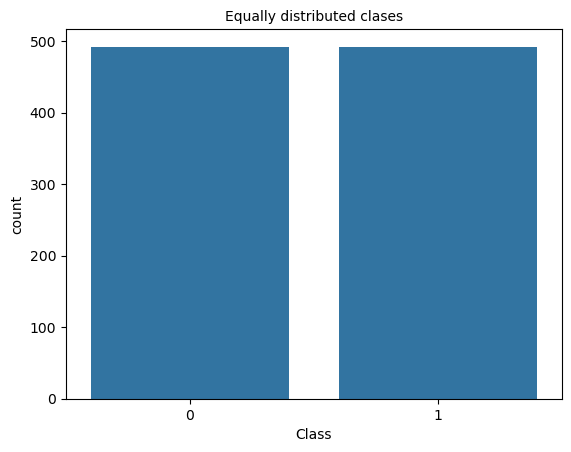

In [20]:
# Now that we have our dataframe correctly balanced, we can perform analysis  and data preprocessing

print(new_df['Class'].value_counts()/len(new_df))

sns.countplot(x='Class', data=new_df)
plt.title("Equally distributed clases", fontsize=10)
plt.show()

In [21]:
# just to be sure that our data is 50/50 and no missing values
print(new_df.shape)
print(new_df.isnull().sum().max())

(984, 32)
0


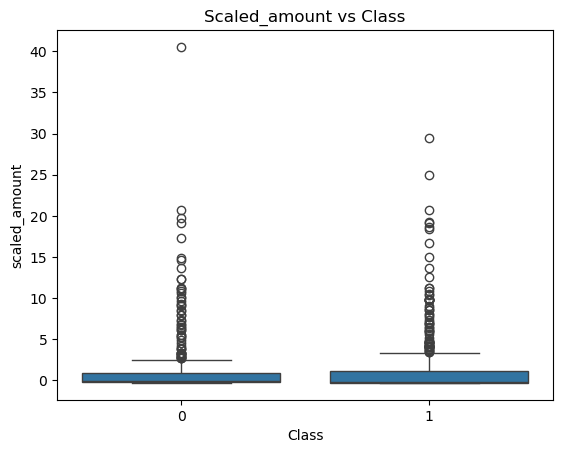

In [22]:
# Scaled amount vs class 

sns.boxplot(x='Class', y='scaled_amount', data=new_df)
plt.title('Scaled_amount vs Class')
plt.show()

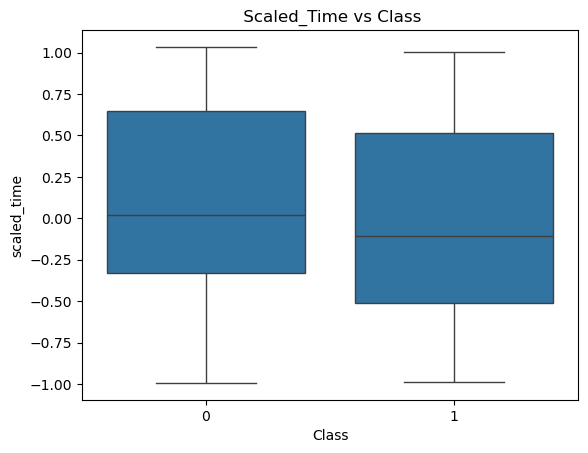

In [23]:
# Time vs class

sns.boxplot(x='Class', y='scaled_time', data=new_df)
plt.title(" Scaled_Time vs Class")
plt.show()

In [24]:
# AMOUNT and TIME are useful but they do not clearly seperate fraud by themselves
new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,scled_amt
82142,-0.167819,-0.298770,1.186888,-0.010985,1.088761,1.223712,-0.701099,0.088916,-0.536331,0.093825,0.853212,-0.215297,-1.153253,0.573878,0.600266,-0.484628,0.161369,0.200210,-0.456038,0.040503,-0.027406,-0.086419,-0.089157,-0.025017,-0.072736,-0.103750,0.497099,-0.379400,0.074932,0.034298,0,-0.167819
239501,3.007895,0.768888,-6.682832,-2.714268,-5.774530,1.449792,-0.661836,-1.148650,0.849686,0.433427,-1.315646,-2.796332,-0.448794,-2.562602,0.243483,-1.181669,0.004373,-2.302596,-4.446192,-1.710463,0.982729,-1.928527,0.220526,1.187013,0.335821,0.215683,0.803110,0.044033,-0.054988,0.082337,1,3.007895
73895,0.619577,-0.344952,-0.566769,0.745102,1.152889,0.948425,0.088301,-0.855525,0.817246,-0.087512,-0.451307,-0.035742,-0.620586,-0.449091,-0.585624,0.450231,1.099053,-0.298456,-0.154766,0.208712,0.390176,0.284910,0.155708,0.421235,0.029476,0.374882,-0.181086,-0.317216,0.384532,0.233225,0,0.619577
131272,-0.304618,-0.060527,-0.114361,1.036129,1.984405,3.128243,-0.740344,1.548619,-1.701284,-2.203842,-1.242265,0.269562,1.293418,0.933216,-0.135326,0.521484,0.386884,0.059869,0.306339,0.265052,0.223718,0.732852,-1.032935,1.196428,-0.112857,0.254719,0.696668,0.482370,0.129969,0.223924,1,-0.304618
15781,1.089779,-0.675208,-25.266355,14.323254,-26.823673,6.349248,-18.664251,-4.647403,-17.971212,16.633103,-3.768351,-8.303239,4.783257,-6.699252,0.846768,-6.576276,-0.062330,-5.961660,-12.218482,-4.791842,0.894854,1.658289,1.780701,-1.861318,-1.188167,0.156667,1.768192,-0.219916,1.411855,0.414656,1,1.089779


In [25]:
# Identifying features with the strongest positive and negative impact on 'Class'.
# Values near -1 or 1 indicate strong predictive power.

new_df.corr()['Class'].sort_values()


V14             -0.748082
V12             -0.685506
V10             -0.627469
V16             -0.593817
V3              -0.566461
V9              -0.560386
V17             -0.557648
V18             -0.475808
V7              -0.474220
V1              -0.415006
V6              -0.383032
V5              -0.374099
scaled_time     -0.164260
V24             -0.105054
V13             -0.061432
V15             -0.041983
V23             -0.016324
V22              0.007182
V25              0.033061
scaled_amount    0.037243
scled_amt        0.037243
V8               0.059734
V26              0.067091
V27              0.086400
V28              0.097818
V21              0.126559
V20              0.134015
V19              0.252553
V2               0.480031
V11              0.690455
V4               0.713823
Class            1.000000
Name: Class, dtype: float64

In [26]:
df.corr()['Class'].sort_values()

V17             -0.326481
V14             -0.302544
V12             -0.260593
V10             -0.216883
V16             -0.196539
V3              -0.192961
V7              -0.187257
V18             -0.111485
V1              -0.101347
V9              -0.097733
V5              -0.094974
V6              -0.043643
scaled_time     -0.012323
V24             -0.007221
V13             -0.004570
V15             -0.004223
V23             -0.002685
V22              0.000805
V25              0.003308
V26              0.004455
scled_amt        0.005632
scaled_amount    0.005632
V28              0.009536
V27              0.017580
V8               0.019875
V20              0.020090
V19              0.034783
V21              0.040413
V2               0.091289
V4               0.133447
V11              0.154876
Class            1.000000
Name: Class, dtype: float64

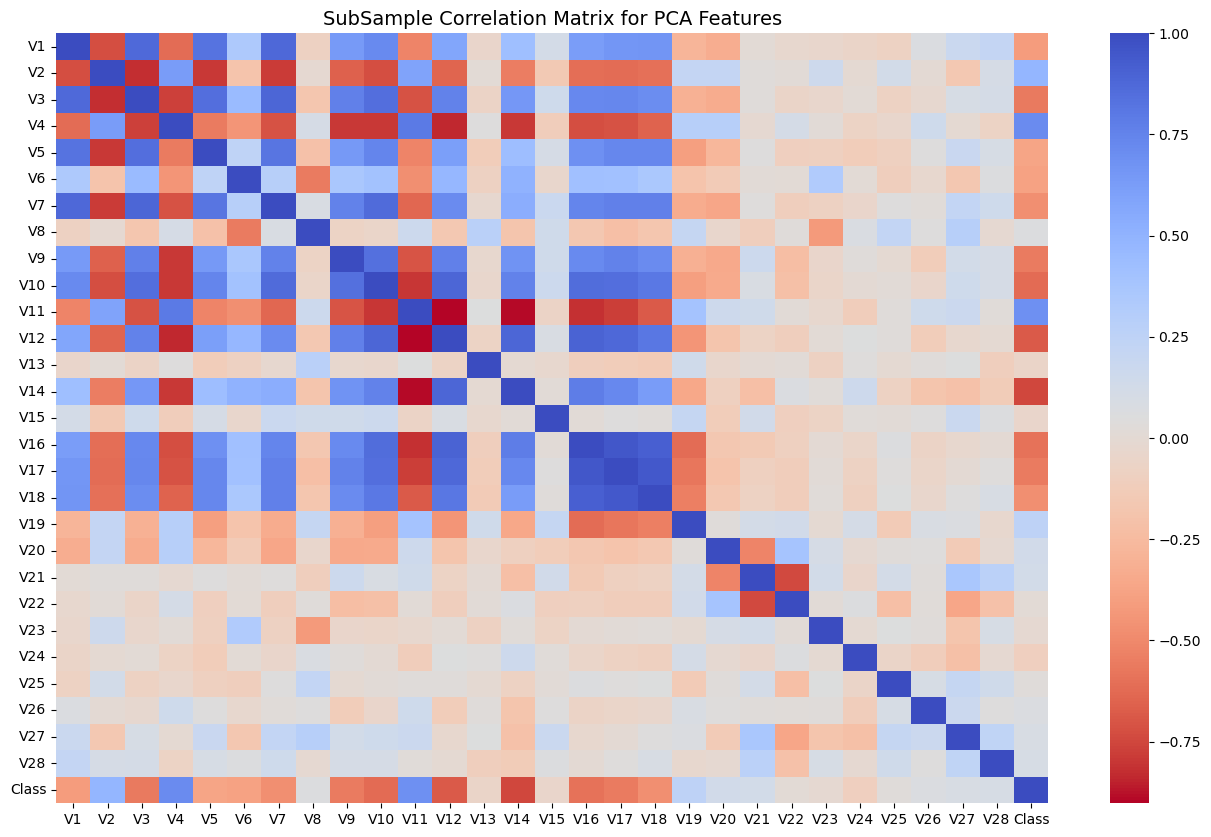

Top 3 features most strongly correlated with Class:
Feature V14: Correlation = -0.7481
Feature V4: Correlation = 0.7138
Feature V11: Correlation = 0.6905
Feature V12: Correlation = -0.6855
Feature V10: Correlation = -0.6275


In [27]:
# Focus only on the PCA features V1-V28 and the Class column
pca_features = [f'V{i}' for i in range(1, 29)] + ['Class']
sub_sample_corr = new_df[pca_features].corr()
# Plot the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size': 10})
plt.title('SubSample Correlation Matrix for PCA Features', fontsize=14)
plt.show()
# Identify the top 3 features with the strongest correlation (positive or negative) to 'Class'
# We drop 'Class' itself from the Series and look at the absolute correlation values
correlations = sub_sample_corr['Class'].drop('Class')
top_3_features = correlations.abs().sort_values(ascending=False).head(5)
print("Top 3 features most strongly correlated with Class:")
for feature, abs_corr in top_3_features.items():
    real_corr = correlations[feature]
    print(f"Feature {feature}: Correlation = {real_corr:.4f}")

In [28]:
# creating an instance
smote = SMOTE(random_state=42)

In [29]:
# while X and y is the same variable used before while X = every column except Class,
# y = class column only
x_smote, y_smote = smote.fit_resample(X, y)

c:\Users\FAROOQUE\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\FAROOQUE\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _w

In [30]:
from collections import Counter
print("Original Dataset districbutions: ", Counter(y))
print("Resampled (SMOTE) dataset distribution: ", Counter(y_smote))

Original Dataset districbutions:  Counter({0: 284315, 1: 492})
Resampled (SMOTE) dataset distribution:  Counter({0: 284315, 1: 284315})


In [ ]:
log_reg = LogisticRegression(max_iter=1000)
f1_scores = []
recall_scores = []

x_smote_np = x_smote.values
y_smote_np = y_smote.values

print(" Training Logistic Reg with K-fold : ")
for train_index, test_index in sss.split(x_smote_np, y_smote_np):
    x_train, x_test = x_smote_np[train_index], x_smote_np[test_index]
    y_train, y_test = y_smote_np[train_index], y_smote_np[test_index]

    log_reg.fit(x_train, y_train)

    y_pred = log_reg.predict(x_test)

    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))

print(f"Mean F1 Score: {np.mean(f1_scores):.4f}")
print(f"Mean Recall Score: {np.mean(recall_scores):.4f}")

 Training Logistic Reg with K-fold : 
Mean F1 Score: 0.9379
Mean Recall Score: 0.9218


In [32]:
from sklearn.ensemble import RandomForestClassifier

randomforest = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_f1_scores = []
rf_recall_scores = []

print("Training with Random Forest with K-Fold : ")
for train_index, test_index in sss.split(x_smote_np, y_smote_np):
    X_train, X_test = x_smote_np[train_index], x_smote_np[test_index]
    y_train, y_test = y_smote_np[train_index], y_smote_np[test_index]
    
    # training with Random Forest
    randomforest.fit(X_train, y_train)
    y_pred = randomforest.predict(X_test)

    rf_f1_scores.append(f1_score(y_test, y_pred))
    rf_recall_scores.append(recall_score(y_test, y_pred))

print(f"Mean F1 Score: {np.mean(rf_f1_scores): .4f}")
print(f"Mean Recal score: {np.mean(rf_recall_scores): .4f}")

Training with Random Forest with K-Fold : 
Mean F1 Score:  0.8730
Mean Recal score:  0.9789


In [33]:
from xgboost import XGBClassifier

In [34]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth = 6,
    learning_rate = 0.1,
    tree_method='hist',
    random_state=42,
    eval_metric='logloss'
)
xgb_f1_score = []
xgb_recall_score =[]


print("Training XGBoost (GPU) with K-fold : ")
for train_index, test_index in sss.split(x_smote_np, y_smote_np):
    x_train, x_test = x_smote_np[train_index], x_smote_np[test_index]
    y_train, y_test = y_smote_np[train_index], y_smote_np[test_index]
    
    xgb_model.fit(x_train, y_train)
    y_pred = xgb_model.predict(x_test)
    
    xgb_f1_score.append(f1_score(y_test, y_pred))
    xgb_recall_score.append(recall_score(y_test, y_pred))
print(f"Mean F1 Score: {np.mean(xgb_f1_score):.4f}")
print(f"Mean Recall Score: {np.mean(xgb_recall_score):.4f}")


Training XGBoost (GPU) with K-fold : 
Mean F1 Score: 0.9249
Mean Recall Score: 1.0000


In [35]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers: 64 neurons → 32 neurons
    activation='relu',              # ReLU activation function
    max_iter=50,                    # keep it short so it doesn't take forever
    random_state=42,
    verbose=True                    # shows progress while training
)

nn_f1_scores = []
nn_recall_scores = []

print("Training Neural Network with K-fold : ")
for train_index, test_index in sss.split(x_smote_np, y_smote_np):
    x_train, x_test = x_smote_np[train_index], x_smote_np[test_index]
    y_train, y_test = y_smote_np[train_index], y_smote_np[test_index]
    
    nn_model.fit(x_train, y_train)
    y_pred = nn_model.predict(x_test)
    
    nn_f1_scores.append(f1_score(y_test, y_pred))
    nn_recall_scores.append(recall_score(y_test, y_pred))

print(f"\nMean F1 Score: {np.mean(nn_f1_scores):.4f}")
print(f"Mean Recall Score: {np.mean(nn_recall_scores):.4f}")


Training Neural Network with K-fold : 
Iteration 1, loss = 0.03873106
Iteration 2, loss = 0.00666452
Iteration 3, loss = 0.00379076
Iteration 4, loss = 0.00306377
Iteration 5, loss = 0.00223773
Iteration 6, loss = 0.00212185
Iteration 7, loss = 0.00157672
Iteration 8, loss = 0.00161488
Iteration 9, loss = 0.00138501
Iteration 10, loss = 0.00133211
Iteration 11, loss = 0.00118981
Iteration 12, loss = 0.00107336
Iteration 13, loss = 0.00099769
Iteration 14, loss = 0.00087597
Iteration 15, loss = 0.00099244
Iteration 16, loss = 0.00075589
Iteration 17, loss = 0.00095001
Iteration 18, loss = 0.00070062
Iteration 19, loss = 0.00087196
Iteration 20, loss = 0.00076425
Iteration 21, loss = 0.00083376
Iteration 22, loss = 0.00069968
Iteration 23, loss = 0.00070699
Iteration 24, loss = 0.00074421
Iteration 25, loss = 0.00056138
Iteration 26, loss = 0.00074344
Iteration 27, loss = 0.00063845
Iteration 28, loss = 0.00055259
Iteration 29, loss = 0.00049197
Iteration 30, loss = 0.00069053
Iteration 

=== Neural Network - Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56863
       Fraud       0.67      1.00      0.80        98

    accuracy                           1.00     56961
   macro avg       0.83      1.00      0.90     56961
weighted avg       1.00      1.00      1.00     56961



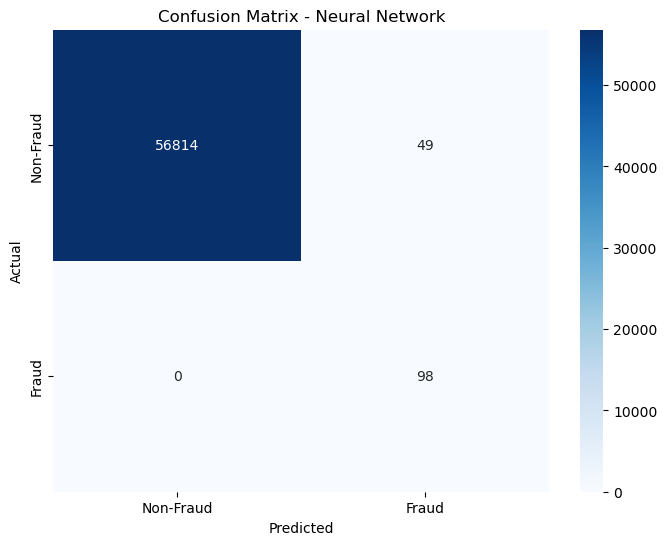

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the ORIGINAL test data (from cell 15's stratified split)
y_pred_nn = nn_model.predict(original_Xtest)

# Classification Report
print("=== Neural Network - Classification Report ===")
print(classification_report(original_ytest, y_pred_nn, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(original_ytest, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Best Threshold: 0.9973
F1 at best threshold: 0.9469
Precision at best threshold: 0.8991
Recall at best threshold: 1.0000


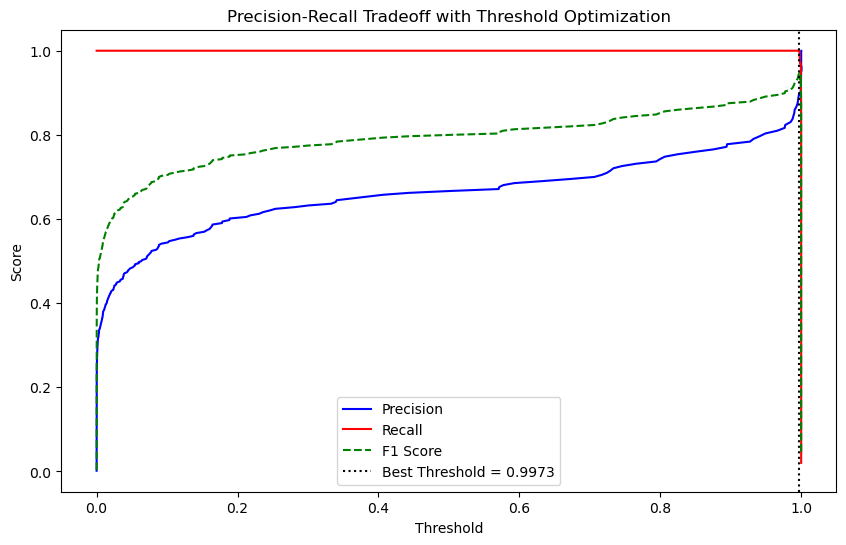

In [37]:
from sklearn.metrics import precision_recall_curve

# Get probability scores instead of hard predictions
y_proba = nn_model.predict_proba(original_Xtest)[:, 1]

# Calculate precision and recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(original_ytest, y_proba)

# Find the threshold that maximizes F1
f1_all = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_all)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"F1 at best threshold: {f1_all[best_idx]:.4f}")
print(f"Precision at best threshold: {precisions[best_idx]:.4f}")
print(f"Recall at best threshold: {recalls[best_idx]:.4f}")

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.plot(thresholds, f1_all[:-1], label='F1 Score', color='green', linestyle='--')
plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best Threshold = {best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff with Threshold Optimization')
plt.legend()
plt.show()


=== XGB Model - Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.73      0.84     56863
       Fraud       0.01      1.00      0.01        98

    accuracy                           0.73     56961
   macro avg       0.50      0.86      0.43     56961
weighted avg       1.00      0.73      0.84     56961



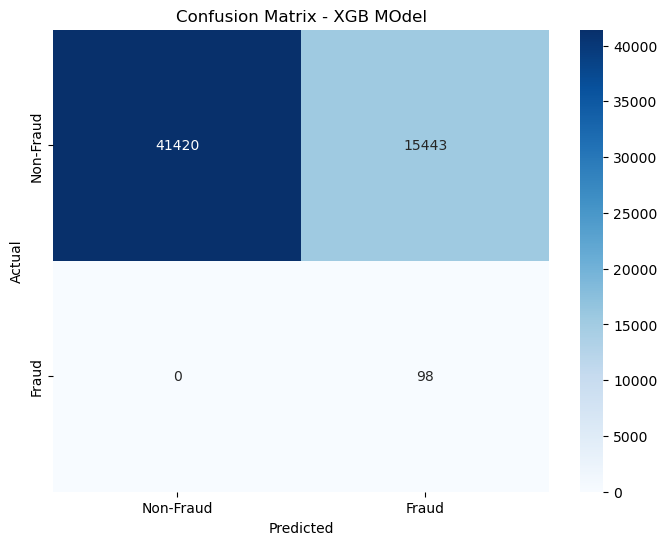

In [38]:
# Predict on the ORIGINAL test data (from cell 15's stratified split)
y_pred_xgb = xgb_model.predict(original_Xtest)

# Classification Report
print("=== XGB Model - Classification Report ===")
print(classification_report(original_ytest, y_pred_xgb, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(original_ytest, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - XGB MOdel')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


=== XGB Model - Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.24      0.38     56863
       Fraud       0.00      1.00      0.00        98

    accuracy                           0.24     56961
   macro avg       0.50      0.62      0.19     56961
weighted avg       1.00      0.24      0.38     56961



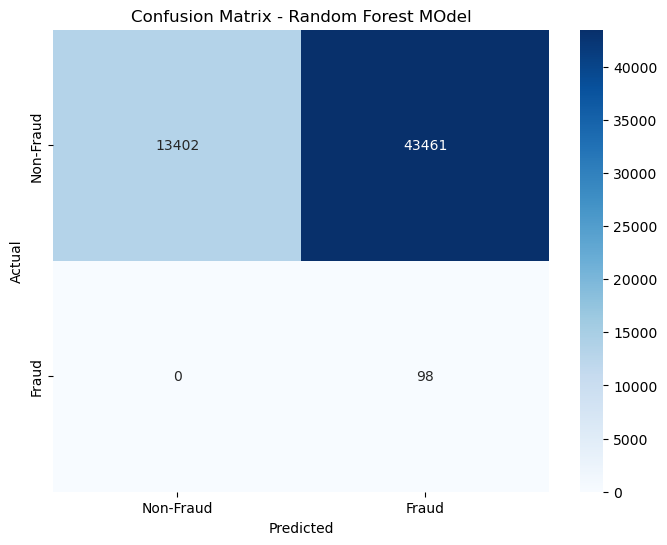

In [39]:

# Predict on the ORIGINAL test data (from cell 15's stratified split)
y_pred_rf = randomforest.predict(original_Xtest)

# Classification Report
print("=== XGB Model - Classification Report ===")
print(classification_report(original_ytest, y_pred_rf, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(original_ytest, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - Random Forest MOdel')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


=== log_reg Model - Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.97      0.98     56863
       Fraud       0.04      0.92      0.08        98

    accuracy                           0.97     56961
   macro avg       0.52      0.94      0.53     56961
weighted avg       1.00      0.97      0.98     56961



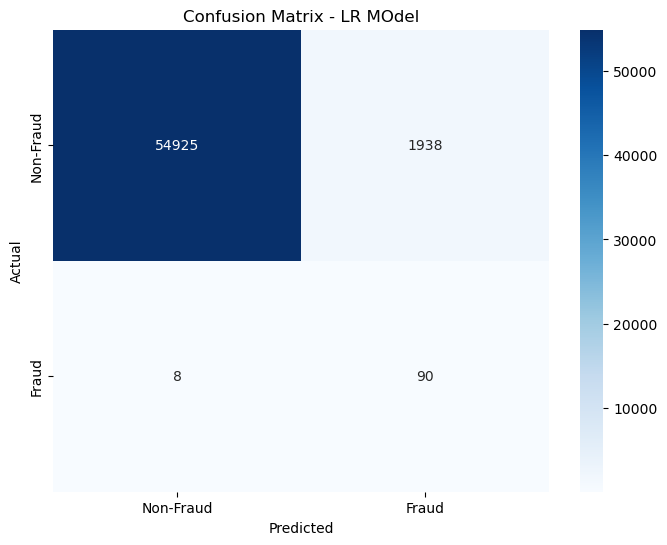

In [40]:
# Predict on the ORIGINAL test data (from cell 15's stratified split)
y_pred_lr = log_reg.predict(original_Xtest)

# Classification Report
print("=== log_reg Model - Classification Report ===")
print(classification_report(original_ytest, y_pred_lr, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(original_ytest, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - LR MOdel')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Neural Network is the winner
Neural network results were better than baseline mmodel(Logistics Regression) and the ensemble models(RandomForest and XGBoost) as well - 
 - Best Threshold: 0.9978
 - F1 at best threshold: 0.9353
 - Precision at best threshold: 0.9126
 - Recall at best threshold: 0.9592


In [ ]:
import joblib
# create models directory if it doesnt exist
os.makedirs('models', exist_ok=True)

# save the neural network model
joblib.dump(nn_model, 'models/fraud_model.pkl')

# save the RobustScaler (preprocessing)
joblib.dump(robust_scaler, 'models/rbscaler.pkl')

print("Model and scaler is saved in the folder")


Model and scaler is saved in the folder


In [47]:
# load the models and scaler
loaded_model = joblib.load('models/fraud_model.pkl')
loaded_scaler = joblib.load('models/rbscaler.pkl')

# create dummy transactions(29 features matching our training datset)
dummy_trans = np.random.randn(1, 31)

# predict
prediction = loaded_model.predict(dummy_trans)
result = "Fraudaulent " if prediction[0] == 1 else "Legitimate"

print(f"Transaction Prediction: {result}")
print(f"Raw Prediction value: {prediction[0]}")

Transaction Prediction: Legitimate
Raw Prediction value: 0


In [50]:
# load the models and scaler
loaded_model = joblib.load('models/fraud_model.pkl')
loaded_scaler = joblib.load('models/rbscaler.pkl')

# create dummy transactions(29 features matching our training datset)
dummy_transact = np.random.randn(1, 31)

# predict
prediction = loaded_model.predict(dummy_transact)
result = "Fraudaulent " if prediction[0] == 1 else "Legitimate"

print(f"Transaction Prediction: {result}")
print(f"Raw Prediction value: {prediction[0]}")

Transaction Prediction: Legitimate
Raw Prediction value: 0


In [51]:
import numpy as np

# Test 1: Random data (should be Legitimate)
random_trans = np.random.randn(1, 31)

# Test 2: Use a REAL fraud transaction from the original test data
real_fraud_idx = np.where(original_ytest == 1)[0][0]  # find first real fraud
real_fraud = original_Xtest[real_fraud_idx].reshape(1, -1)

# Test 3: Use a REAL legitimate transaction
real_legit_idx = np.where(original_ytest == 0)[0][0]  # find first real non-fraud
real_legit = original_Xtest[real_legit_idx].reshape(1, -1)

# Predict all three
for name, transaction in [("Random Data", random_trans), 
                           ("Real Fraud", real_fraud), 
                           ("Real Legitimate", real_legit)]:
    pred = loaded_model.predict(transaction)
    result = "Fraudulent" if pred[0] == 1 else "Legitimate"
    print(f"{name} → Prediction: {result}")


Random Data → Prediction: Legitimate
Real Fraud → Prediction: Fraudulent
Real Legitimate → Prediction: Legitimate
